# HOMEWORK 2

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW2

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input images
# hm_version = 2
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone images
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"



For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [3]:
# Load data

import cv2
import apps.reporter as rpt
from pathlib import Path

# Input data
file_name = "resources/images/sea.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_r, img_g, img_b = cv2.split(img_rgb)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(756, 1008, 3)"


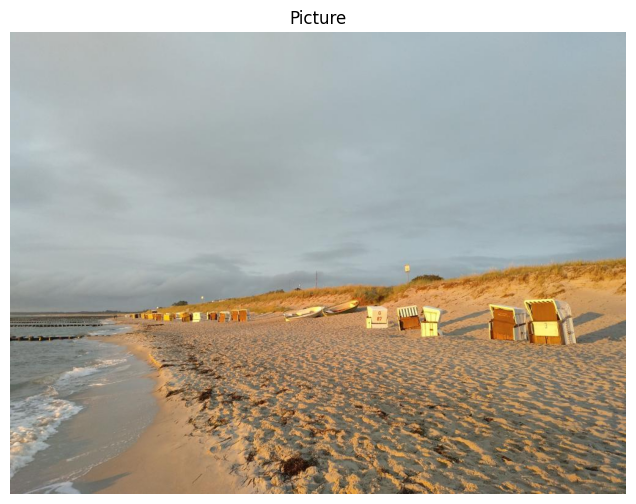

In [4]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Picture")
plt.show()


### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

In [5]:
# White patch

import cv2
import numpy as np

# Input data
row, col = 485, 864
white = img_rgb[row, col, :]

# Solution

# Define white patch and the coefficients
coeffs = 255.0 / white

# Apply white balancing and generate balanced image
balanced_wp = np.zeros_like(img_rgb, dtype=np.float32)
for channel in range(3):
    balanced_wp[..., channel] = img_rgb[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
# Variant 1
# balanced = balanced / 255
# balanced[balanced > 1] = 1
# Variant 2
balanced_wp = np.clip(balanced_wp, 0, 255).astype(np.uint8)

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Point: (R, G, B)", rp.format_matrix(white))
rp.add_item("Coefficients: (k_r, k_g, k_b)", rp.format_matrix(coeffs))

# Print results
rp.print_pd_report("Image processing")


Attribute,Result
"Point: (R, G, B)",[252 242 127]
"Coefficients: (k_r, k_g, k_b)",[1.01 1.05 2.01]


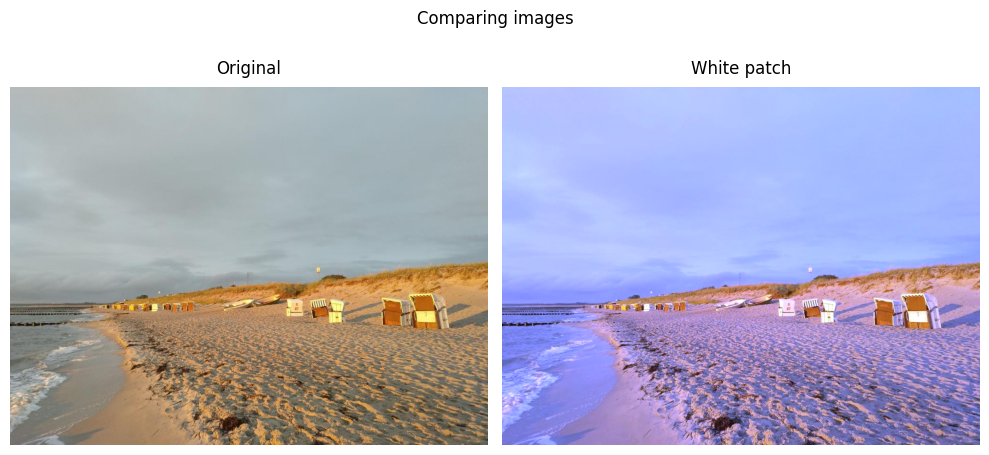

In [6]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_wp

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("White patch", pad=10, loc='center', color='black')

# Plot
plt.suptitle("Comparing images")
plt.tight_layout()
plt.show()


### Gray world
This algorithm assumes that a scene, on average, is gray.

In [7]:
# Gray world V1 (HSV)

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_v = cv2.split(img_hsv)[2]

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img_r).astype(float)
mean_g = np.mean(img_g).astype(float)
mean_b = np.mean(img_b).astype(float)

# condition
mean_v = np.mean(img_v).astype(float)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = mean_v / mean_r
kg = mean_v / mean_g
kb = mean_v / mean_b

temp_r = img_r * kr
temp_g = img_g * kg
temp_b = img_b * kb

# Apply color balancing and generate the balanced image
balanced_gw_hsv = cv2.merge([temp_r, temp_g, temp_b])
balanced_gw_hsv = np.clip(balanced_gw_hsv, 0, 255).astype(np.uint8)

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Mean: R", rp.format_value(mean_r))
rp.add_item("Mean: G", rp.format_value(mean_g))
rp.add_item("Mean: B", rp.format_value(mean_b))
rp.add_item("Color space", "HSV")
rp.add_item("Channel from color space", "V - Value")
rp.add_item("Mean: V", rp.format_value(mean_v))
rp.add_item("Coefficients: (k_r, k_g, k_b)", rp.format_matrix(np.array([kr, kg, kb])))

# Print results
rp.print_pd_report("Image processing")


Attribute,Result
Mean: R,162.26
Mean: G,156.82
Mean: B,144.08
Color space,HSV
Channel from color space,V - Value
Mean: V,170.97
"Coefficients: (k_r, k_g, k_b)",[1.05 1.09 1.19]


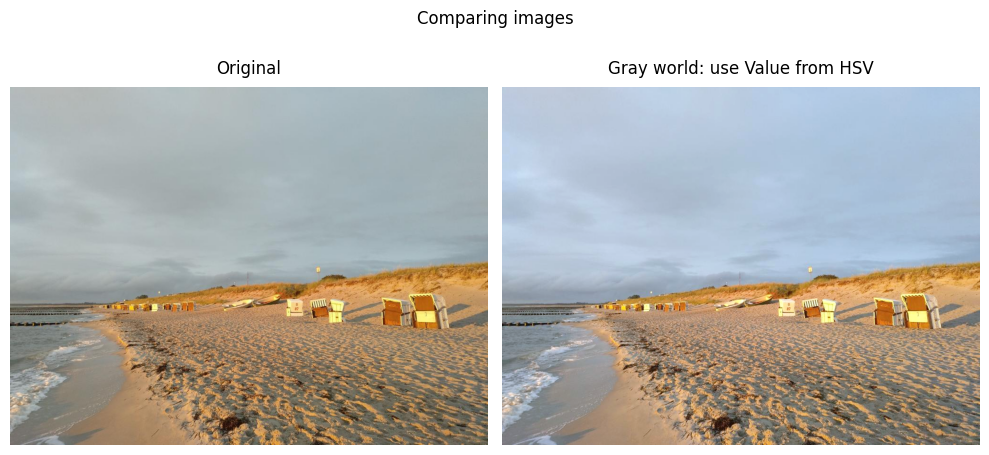

In [8]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_gw_hsv

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("Gray world: use Value from HSV", pad=10, loc='center', color='black')

# Plot
plt.suptitle("Comparing images")
plt.tight_layout()
plt.show()


In [9]:
# Gray world V2 (HSL)

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
img_hsl = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
img_l = cv2.split(img_hsl)[1]

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img_r).astype(float)
mean_g = np.mean(img_g).astype(float)
mean_b = np.mean(img_b).astype(float)

# condition
mean_l = np.mean(img_l).astype(float)

# Compute the coefficients kr, kg, kb
kr = mean_l / mean_r
kg = mean_l / mean_g
kb = mean_l / mean_b

temp_r = img_r * kr
temp_g = img_g * kg
temp_b = img_b * kb

# Apply color balancing and generate the balanced image
balanced_gw_hsl = cv2.merge([temp_r, temp_g, temp_b])
balanced_gw_hsl = np.clip(balanced_gw_hsl, 0, 255).astype(np.uint8)

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Mean: R", rp.format_value(mean_r))
rp.add_item("Mean: G", rp.format_value(mean_g))
rp.add_item("Mean: B", rp.format_value(mean_b))
rp.add_item("Color space", "HSL")
rp.add_item("Channel from color space", "L - Luminance")
rp.add_item("Mean: L", rp.format_value(mean_l))
rp.add_item("Coefficients: (k_r, k_g, k_b)", rp.format_matrix(np.array([kr, kg, kb])))

# Print results
rp.print_pd_report("Image processing")


Attribute,Result
Mean: R,162.26
Mean: G,156.82
Mean: B,144.08
Color space,HSL
Channel from color space,L - Luminance
Mean: L,153.40
"Coefficients: (k_r, k_g, k_b)",[0.95 0.98 1.06]


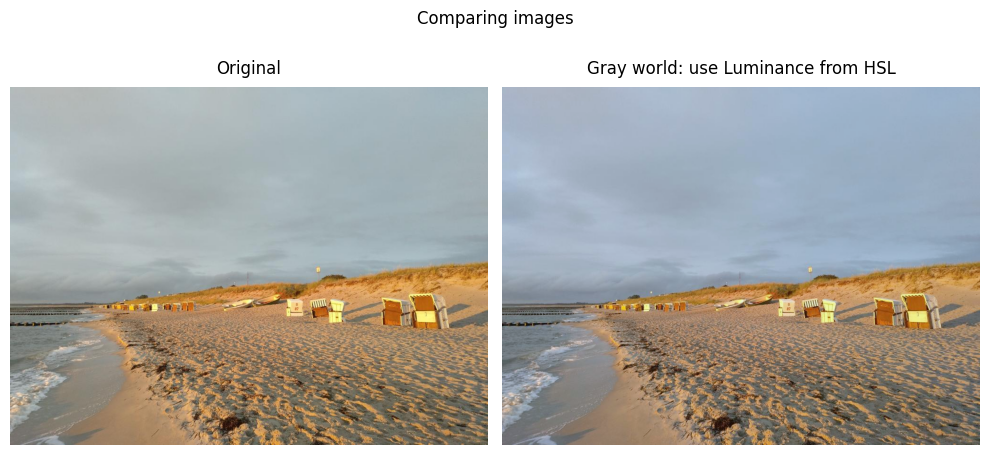

In [10]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_gw_hsl

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("Gray world: use Luminance from HSL", pad=10, loc='center', color='black')

# Plot
plt.suptitle("Comparing images")
plt.tight_layout()
plt.show()


In [21]:
# Gray world V3 (YCrCb)

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
img_YCrCb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
img_y = cv2.split(img_hsl)[0]

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img_r).astype(float)
mean_g = np.mean(img_g).astype(float)
mean_b = np.mean(img_b).astype(float)

# condition
mean_y = np.mean(img_y).astype(float)

# Compute the coefficients kr, kg, kb
kr = mean_y / mean_r
kg = mean_y / mean_g
kb = mean_y / mean_b

temp_r = img_r * kr
temp_g = img_g * kg
temp_b = img_b * kb

# Apply color balancing and generate the balanced image
balanced_gw_YCrCb = cv2.merge([temp_r, temp_g, temp_b])
balanced_gw_YCrCb = np.clip(balanced_gw_YCrCb, 0, 255).astype(np.uint8)

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Mean: R", rp.format_value(mean_r))
rp.add_item("Mean: G", rp.format_value(mean_g))
rp.add_item("Mean: B", rp.format_value(mean_b))
rp.add_item("Color space", "YCrCb")
rp.add_item("Channel from color space", "Y - Luma")
rp.add_item("Mean: Y", rp.format_value(mean_y))
rp.add_item("Coefficients: (k_r, k_g, k_b)", rp.format_matrix(np.array([kr, kg, kb])))

# Print results
rp.print_pd_report("Image processing")


Attribute,Result
Mean: R,162.26
Mean: G,156.82
Mean: B,144.08
Color space,YCrCb
Channel from color space,Y - Luma
Mean: Y,62.27
"Coefficients: (k_r, k_g, k_b)",[0.38 0.4 0.43]


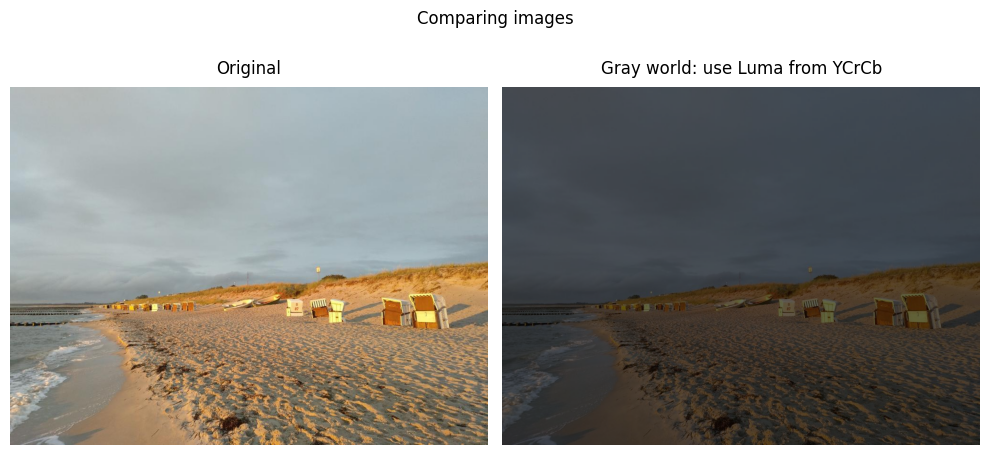

In [25]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_gw_YCrCb

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("Gray world: use Luma from YCrCb", pad=10, loc='center', color='black')

# Plot
plt.suptitle("Comparing images")
plt.tight_layout()
plt.show()


In [23]:
# Gray world V4 (HSI)

import cv2
import numpy as np
import apps.reporter as rpt

# Input data

# Solution
img_i = np.mean(img_bgr, axis=2, dtype=np.float32).astype(np.uint8)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = np.mean(img_r).astype(float)
mean_g = np.mean(img_g).astype(float)
mean_b = np.mean(img_b).astype(float)

# condition
mean_i = np.mean(img_i).astype(float)

# Compute the coefficients kr, kg, kb
kr = mean_i / mean_r
kg = mean_i / mean_g
kb = mean_i / mean_b

temp_r = img_r * kr
temp_g = img_g * kg
temp_b = img_b * kb

# Apply color balancing and generate the balanced image
balanced_gw_hsi = cv2.merge([temp_r, temp_g, temp_b])
balanced_gw_hsi = np.clip(balanced_gw_hsi, 0, 255).astype(np.uint8)

rp = rpt.Reporter()
rp.tolerance = 2
rp.add_item("Mean: R", rp.format_value(mean_r))
rp.add_item("Mean: G", rp.format_value(mean_g))
rp.add_item("Mean: B", rp.format_value(mean_b))
rp.add_item("Color space", "HSI")
rp.add_item("Channel from color space", "I - Intensity")
rp.add_item("Mean: I", rp.format_value(mean_i))
rp.add_item("Coefficients: (k_r, k_g, k_b)", rp.format_matrix(np.array([kr, kg, kb])))

# Print results
rp.print_pd_report("Image processing")


Attribute,Result
Mean: R,162.26
Mean: G,156.82
Mean: B,144.08
Color space,HSI
Channel from color space,I - Intensity
Mean: I,154.07
"Coefficients: (k_r, k_g, k_b)",[0.95 0.98 1.07]


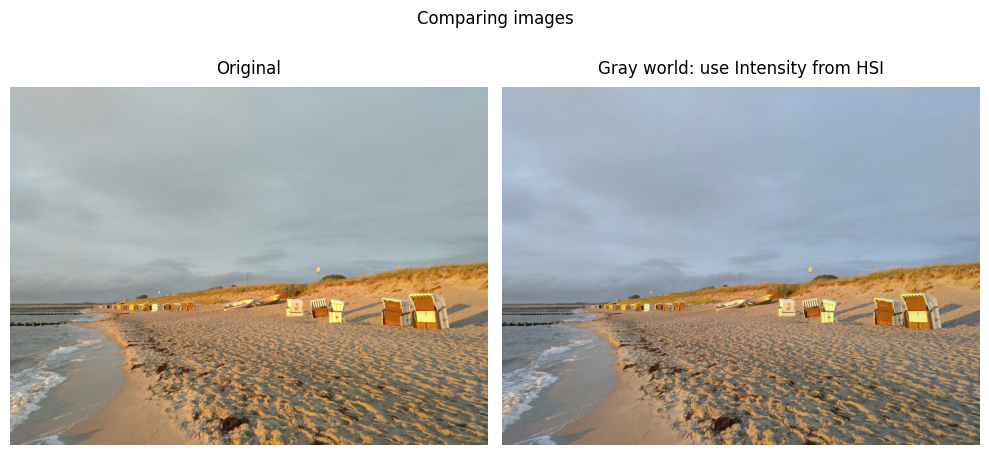

In [26]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_gw_hsi

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("Gray world: use Intensity from HSI", pad=10, loc='center', color='black')

# Plot
plt.suptitle("Comparing images")
plt.tight_layout()
plt.show()


### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

In [ ]:
# Load your image
img = cv2.imread('...')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r =
max_g =
max_b =

# Apply scale-by-max balancing and generate the balanced image
balanced =

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)